## Water Quality Prediction using Deep Learning Neural Networks with PyTorch
## Dataset: Central Pollution Control Board (CPCB) Water Quality Data

In [1]:
# Import necessary libraries
import pandas as pd  # For data manipulation and analysis
import os  # For operating system related operations
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For data visualization
import seaborn as sns  # For enhanced data visualization
from sklearn.model_selection import train_test_split  # For splitting data into training and testing sets
from sklearn.preprocessing import StandardScaler, LabelEncoder  # For feature scaling and encoding categorical variables
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score, mean_squared_error  # For model evaluation
import torch  # PyTorch deep learning framework
import torch.nn as nn  # Neural network modules
import torch.optim as optim  # Optimization algorithms
from torch.utils.data import DataLoader, TensorDataset  # For data loading and batching
import torch.nn.functional as F  # Functional interface for neural network operations
from sklearn.metrics import f1_score  # For F1 score calculation
import warnings  # For handling warning messages
warnings.filterwarnings('ignore')  # Suppress warning messages for cleaner output

In [2]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.7.1+cpu
CUDA available: False


In [3]:
#changing the work directory
os.chdir('/Users/dayod/Deep Learning')


## 1. Data Loading and Exploration


In [4]:
# Load the dataset
df = pd.read_csv('water_quality.csv')

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


Dataset Shape: (19029, 24)

Column Names:
['Well_ID', 'State', 'District', 'Block', 'Village', 'Latitude', 'Longitude', 'Year', 'pH', 'EC', 'CO3', 'HCO3', 'Cl', 'SO4', 'NO3', 'TH', 'Ca', 'Mg', 'Na', 'K', 'F', 'TDS', 'WQI', 'Water Quality Classification']

First 5 rows:
            Well_ID             State    District      Block    Village  \
0  W232200071580001           Gujarat   Ahmedabad     Mandal      Dalod   
1  W254029084355301  Himachal Pradesh       Solan  Nallagarh   JAGATPUR   
2  W193530074180001       Maharashtra  Ahmednagar  SANGAMNER  Kokangaon   
3  W231620072033001           Gujarat   Ahmedabad   Viramgam      Endla   
4  W251908084361501  Himachal Pradesh       Solan  Nallagarh     BARUNA   

   Latitude  Longitude  Year    pH       EC  ...    NO3      TH     Ca     Mg  \
0       NaN        NaN  2020  8.20  16640.0  ...  26.00  1451.0  152.0  260.0   
1   31.1594  76.678500  2019  8.44    299.0  ...   2.70    84.0   17.0   10.0   
2   74.3000  19.591667  2022  7.90  


## 2. Exploratory Data Analysis


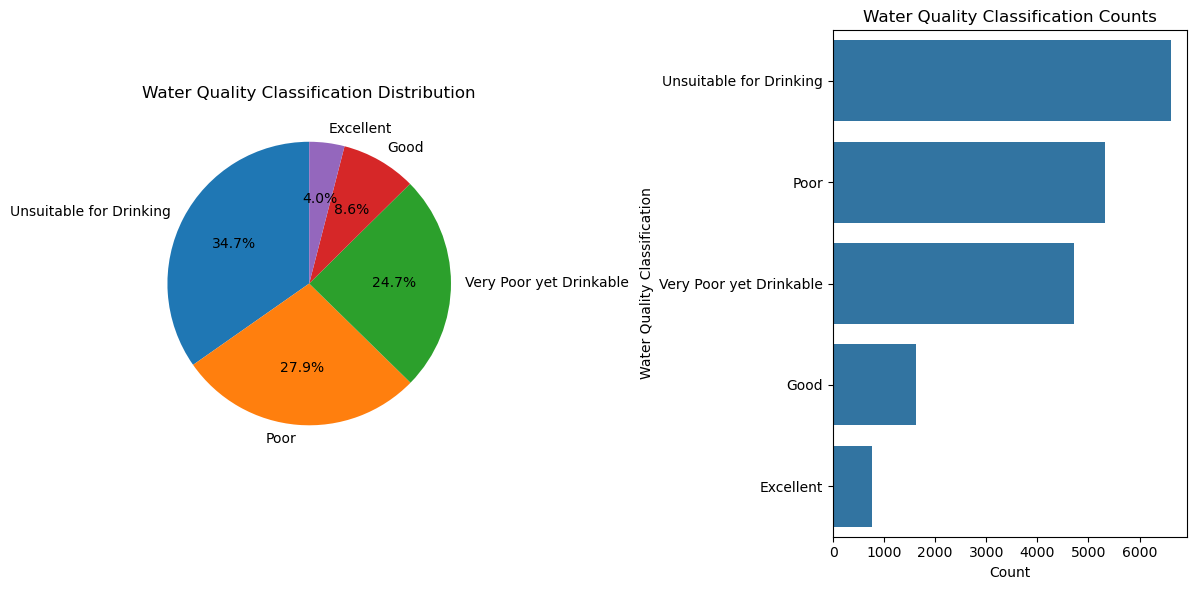

In [5]:
# Create a figure with a specific size (12 inches width, 6 inches height)
plt.figure(figsize=(12, 6))

# Create the first subplot (pie chart)
plt.subplot(1, 2, 1)
# Count the occurrences of each water quality classification
class_counts = df['Water Quality Classification'].value_counts()
# Create a pie chart showing the distribution of water quality classifications
plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Water Quality Classification Distribution')

# Create the second subplot (count plot)
plt.subplot(1, 2, 2)
# Create a horizontal bar chart showing the count of each water quality classification
sns.countplot(data=df, y='Water Quality Classification', order=class_counts.index)
plt.title('Water Quality Classification Counts')
plt.xlabel('Count')

# Adjust the layout to prevent overlap between subplots
plt.tight_layout()
# Display the figure with both visualizations
plt.show()

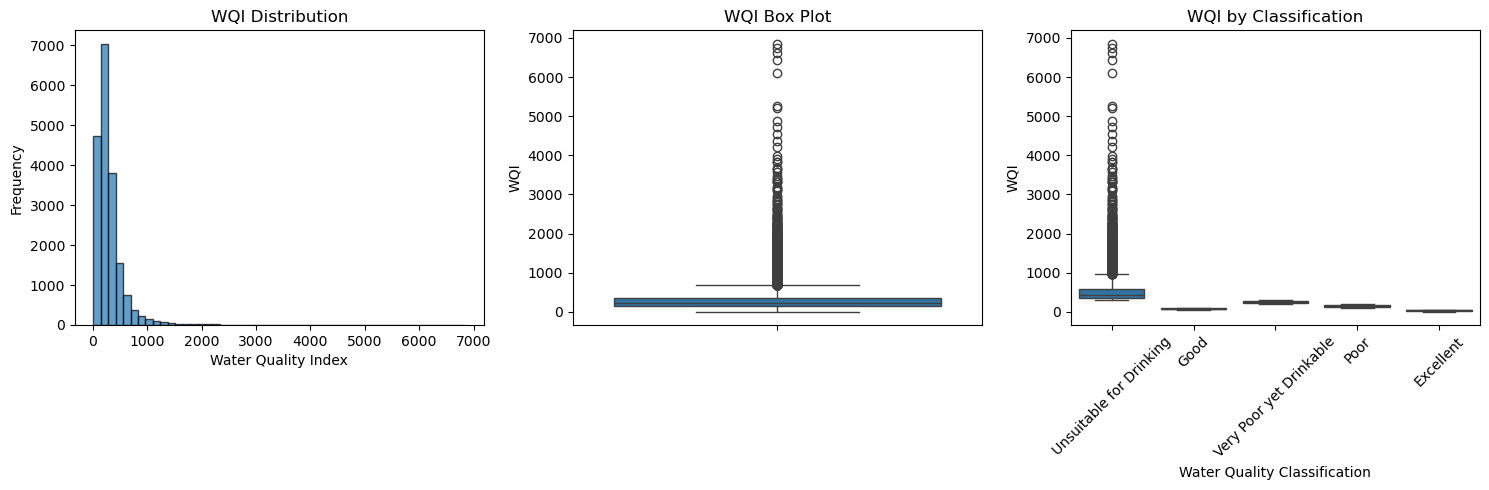

In [31]:
# WQI Distribution.
plt.figure(figsize=(15, 5))  # Create a figure with width 15 inches and height 5 inches

# First subplot: Histogram of WQI values
plt.subplot(1, 3, 1)  # Create a 1x3 grid of subplots and select the first one
plt.hist(df['WQI'], bins=50, edgecolor='black', alpha=0.7)  # Create histogram with 50 bins and semi-transparent bars
plt.title('WQI Distribution')  # Add title to the histogram
plt.xlabel('Water Quality Index')  # Label for x-axis
plt.ylabel('Frequency')  # Label for y-axis

# Second subplot: Box plot of WQI
plt.subplot(1, 3, 2)  # Select the second subplot
sns.boxplot(y=df['WQI'])  # Create a vertical box plot of WQI values
plt.title('WQI Box Plot')  # Add title to the box plot

# Third subplot: Box plot of WQI grouped by water quality classification
plt.subplot(1, 3, 3)  # Select the third subplot
sns.boxplot(data=df, x='Water Quality Classification', y='WQI')  # Create box plot with classifications on x-axis and WQI on y-axis
plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees for better readability
plt.title('WQI by Classification')  # Add title to the grouped box plot

plt.tight_layout()  # Adjust subplot parameters to give specified padding and prevent overlap
plt.show()  # Display all three plots

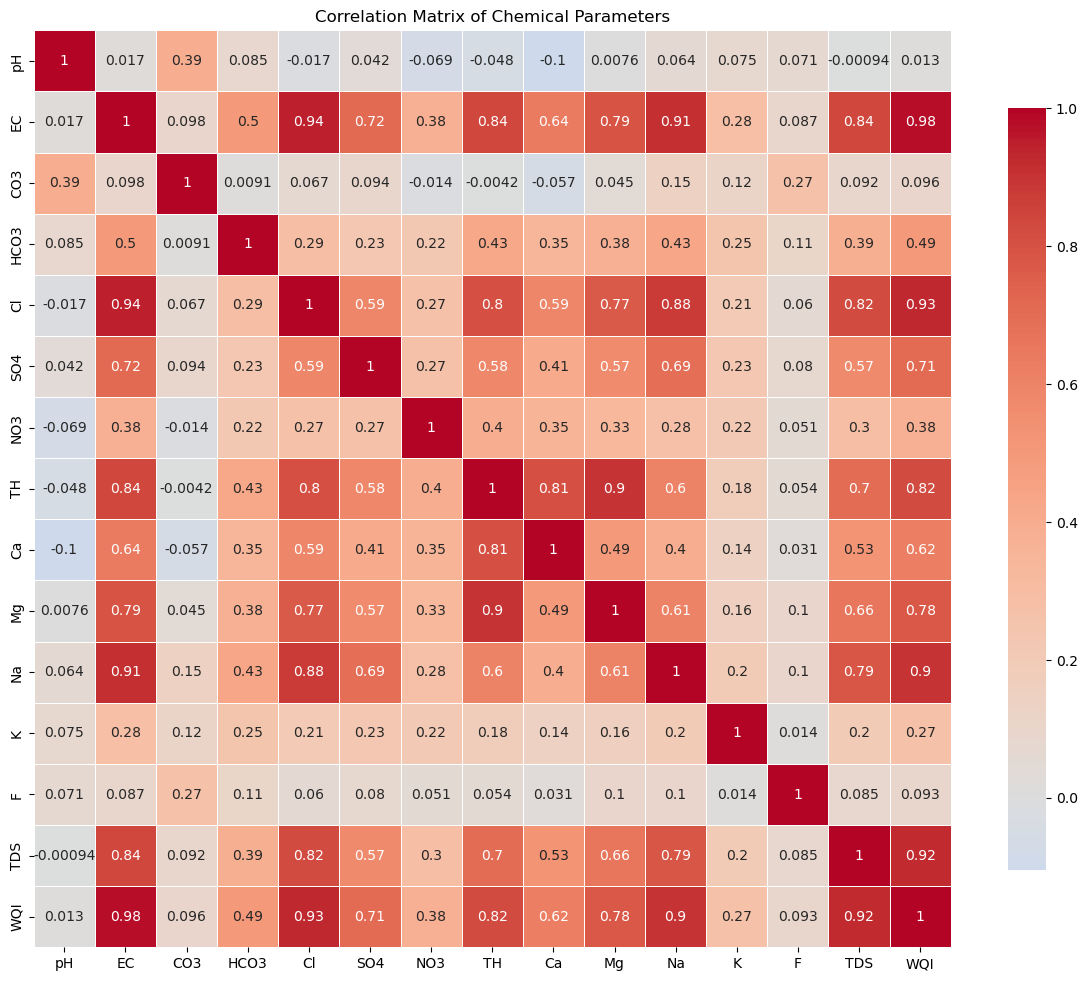

In [7]:
# Correlation Matrix for Chemical Parameters
# Define a list of chemical parameters to analyze
chemical_params = ['pH', 'EC', 'CO3', 'HCO3', 'Cl', 'SO4', 'NO3', 'TH', 'Ca', 'Mg', 'Na', 'K', 'F', 'TDS', 'WQI']
# Calculate the correlation matrix between all chemical parameters
correlation_matrix = df[chemical_params].corr()

# Create a figure with specified size (12x10 inches)
plt.figure(figsize=(12, 10))
# Generate a heatmap visualization of the correlation matrix
# annot=True: Show correlation values in each cell
# cmap='coolwarm': Use a blue-red color scheme (negative to positive correlations)
# center=0: Center the color scale at 0
# square=True: Make cells square-shaped
# linewidths=0.5: Add thin lines between cells
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
# Add a title to the plot
plt.title('Correlation Matrix of Chemical Parameters')
# Adjust layout to ensure everything fits properly
plt.tight_layout()
# Display the plot
plt.show()

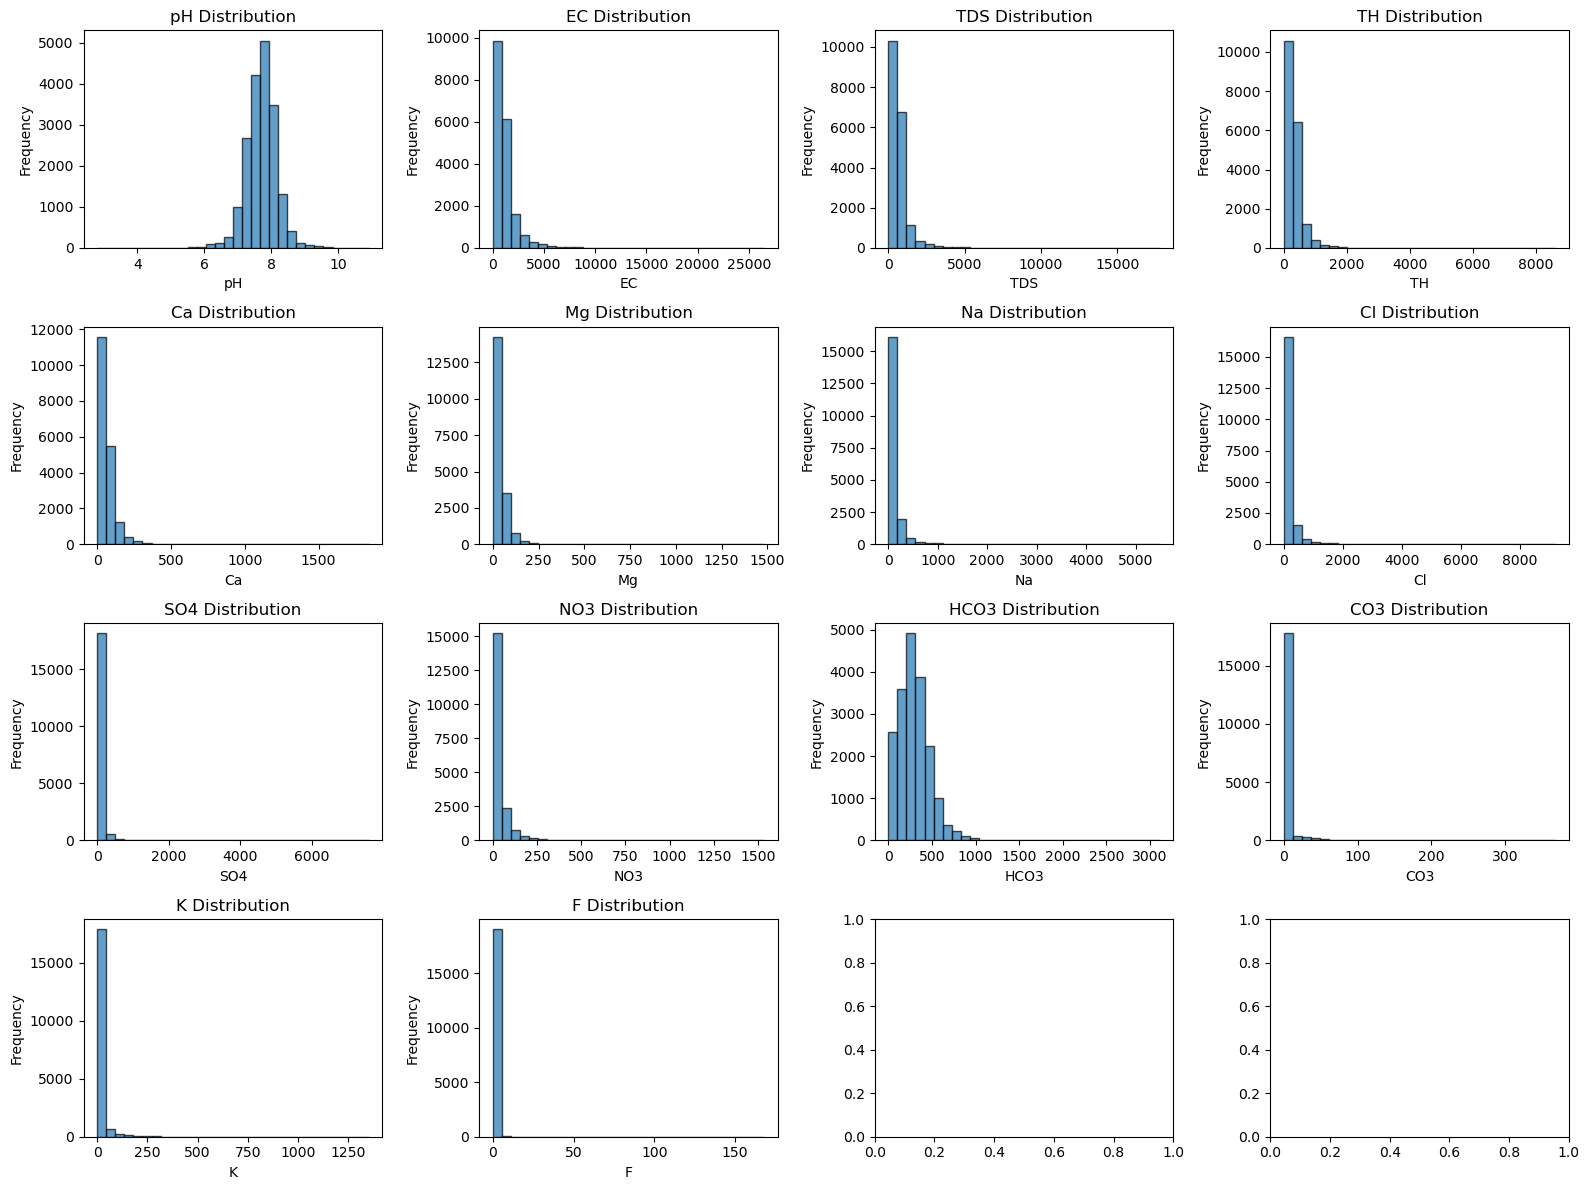

In [8]:
# Feature distributions
fig, axes = plt.subplots(4, 4, figsize=(16, 12))  # Create a 4x4 grid of subplots with specified figure size
axes = axes.ravel()  # Flatten the 2D array of axes into 1D for easier iteration

# List of water quality parameters to visualize
features_to_plot = ['pH', 'EC', 'TDS', 'TH', 'Ca', 'Mg', 'Na', 'Cl', 'SO4', 'NO3', 'HCO3', 'CO3', 'K', 'F']

# Loop through each feature and create a histogram in the corresponding subplot
for i, feature in enumerate(features_to_plot):
    axes[i].hist(df[feature], bins=30, alpha=0.7, edgecolor='black')  # Create histogram with 30 bins and black edges
    axes[i].set_title(f'{feature} Distribution')  # Set the title for each subplot
    axes[i].set_xlabel(feature)  # Set x-axis label
    axes[i].set_ylabel('Frequency')  # Set y-axis label

plt.tight_layout()  # Adjust subplot parameters to give specified padding
plt.show()  # Display the figure


## 3. Data Preprocessing


In [9]:
# Handle missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing Latitude/Longitude with median values
# Using median as it's less affected by outliers than mean
df['Latitude'].fillna(df['Latitude'].median(), inplace=True)
df['Longitude'].fillna(df['Longitude'].median(), inplace=True)

# Create a copy of the dataframe to preserve the original data
# This allows us to perform transformations without affecting the source data
df_processed = df.copy()

# Remove rows with any remaining missing values in chemical parameters
# These parameters are critical for water quality analysis and can't be imputed reliably
chemical_features = ['pH', 'EC', 'CO3', 'HCO3', 'Cl', 'SO4', 'NO3', 'TH', 'Ca', 'Mg', 'Na', 'K', 'F', 'TDS']
df_processed = df_processed.dropna(subset=chemical_features + ['WQI', 'Water Quality Classification'])

# Display the resulting dataset dimensions after cleaning
print(f"\nDataset shape after cleaning: {df_processed.shape}")

Missing values before cleaning:
Well_ID                         3785
State                              0
District                           0
Block                           1119
Village                            1
Latitude                         389
Longitude                        390
Year                               0
pH                                 0
EC                                 0
CO3                                0
HCO3                               0
Cl                                 0
SO4                                0
NO3                                0
TH                                 0
Ca                                 0
Mg                                 0
Na                                 0
K                                  0
F                                  0
TDS                                0
WQI                                0
Water Quality Classification       0
dtype: int64

Dataset shape after cleaning: (19029, 24)


In [10]:
# Define features for modeling
feature_columns = ['Latitude', 'Longitude', 'Year'] + chemical_features

# Prepare features and targets
X = df_processed[feature_columns].copy()
y_regression = df_processed['WQI'].copy()
y_classification = df_processed['Water Quality Classification'].copy()

# Encode categorical target for classification
label_encoder = LabelEncoder()
y_classification_encoded = label_encoder.fit_transform(y_classification)
class_names = label_encoder.classes_

print(f"Number of classes: {len(class_names)}")
print(f"Class names: {class_names}")
print(f"Class distribution: {np.bincount(y_classification_encoded)}")

Number of classes: 5
Class names: ['Excellent' 'Good' 'Poor' 'Unsuitable for Drinking'
 'Very Poor yet Drinkable']
Class distribution: [ 763 1632 5317 6608 4709]



## 4. Train-Test Split and Scaling


In [11]:
# Split the data into training and test sets
# X contains the features
# y_regression contains the continuous target values for regression
# y_classification_encoded contains the encoded categorical target values for classification
# Using 80% of data for training and 20% for testing
# random_state=42 ensures reproducibility
# stratify ensures that the class distribution in y_classification_encoded is preserved in both splits
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_regression, y_classification_encoded, 
    test_size=0.2, random_state=42, stratify=y_classification_encoded
)

# Print the sizes of the resulting datasets to verify the split
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 15223
Test set size: 3806


In [12]:
# Scale features using StandardScaler to normalize data (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit to training data and transform it
X_test_scaled = scaler.transform(X_test)  # Transform test data using the same scaling parameters

# Convert numpy arrays to PyTorch tensors for model training
X_train_tensor = torch.FloatTensor(X_train_scaled)  # Convert training features to float tensor
X_test_tensor = torch.FloatTensor(X_test_scaled)  # Convert test features to float tensor
y_reg_train_tensor = torch.FloatTensor(y_reg_train.values).unsqueeze(1)  # Convert regression target to tensor and add dimension
y_reg_test_tensor = torch.FloatTensor(y_reg_test.values).unsqueeze(1)  # Convert test regression target to tensor
y_clf_train_tensor = torch.LongTensor(y_clf_train)  # Convert classification target to long tensor (for class indices)
y_clf_test_tensor = torch.LongTensor(y_clf_test)  # Convert test classification target to long tensor


## 5. Neural Network Models


In [13]:
class WQIRegressionModel(nn.Module):
    """Neural Network for Water Quality Index (WQI) Regression"""
    
    def __init__(self, input_size, hidden_sizes=[128, 64, 32], dropout_rate=0.3):
        """
        Initialize the WQI regression model.
        
        Args:
            input_size: Number of input features
            hidden_sizes: List of hidden layer sizes (default: [128, 64, 32])
            dropout_rate: Probability of dropping neurons during training (default: 0.3)
        """
        super(WQIRegressionModel, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # Build hidden layers with ReLU activation, BatchNorm, and Dropout
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),  # Linear transformation
                nn.ReLU(),                          # Non-linear activation
                nn.BatchNorm1d(hidden_size),        # Normalize batch to improve training stability
                nn.Dropout(dropout_rate)            # Regularization to prevent overfitting
            ])
            prev_size = hidden_size
        
        # Output layer - single neuron for regression
        layers.append(nn.Linear(prev_size, 1))
        
        # Create sequential model from all layers
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        """
        Forward pass through the network.
        
        Args:
            x: Input tensor of shape [batch_size, input_size]
            
        Returns:
            Predicted WQI value
        """
        return self.network(x)

class WaterQualityClassificationModel(nn.Module):
    """Neural Network for Water Quality Classification"""
    
    def __init__(self, input_size, num_classes, hidden_sizes=[128, 64, 32], dropout_rate=0.3):
        """
        Initialize the water quality classification model.
        
        Args:
            input_size: Number of input features
            num_classes: Number of water quality classes to predict
            hidden_sizes: List of hidden layer sizes (default: [128, 64, 32])
            dropout_rate: Probability of dropping neurons during training (default: 0.3)
        """
        super(WaterQualityClassificationModel, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # Build hidden layers with ReLU activation, BatchNorm, and Dropout
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),  # Linear transformation
                nn.ReLU(),                          # Non-linear activation
                nn.BatchNorm1d(hidden_size),        # Normalize batch to improve training stability
                nn.Dropout(dropout_rate)            # Regularization to prevent overfitting
            ])
            prev_size = hidden_size
        
        # Output layer - multiple neurons for classification (one per class)
        layers.append(nn.Linear(prev_size, num_classes))
        
        # Create sequential model from all layers
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        """
        Forward pass through the network.
        
        Args:
            x: Input tensor of shape [batch_size, input_size]
            
        Returns:
            Logits for each class
        """
        return self.network(x)


## 6. Training Functions


In [14]:
def train_regression_model(model, train_loader, val_loader, epochs=100, lr=0.001):
    """Train the WQI regression model"""
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    train_losses = []
    val_losses = []
    
    best_val_loss = float('inf')
    patience_counter = 0
    early_stopping_patience = 20
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_regression_model.pth')
        else:
            patience_counter += 1
        
        if patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
    
    # Load best model
    model.load_state_dict(torch.load('best_regression_model.pth'))
    
    return train_losses, val_losses

def train_classification_model(model, train_loader, val_loader, epochs=100, lr=0.001):
    """Train the water quality classification model"""
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    best_val_acc = 0.0
    patience_counter = 0
    early_stopping_patience = 20
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += batch_y.size(0)
            correct_train += (predicted == batch_y).sum().item()
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total_val += batch_y.size(0)
                correct_val += (predicted == batch_y).sum().item()
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        train_acc = 100 * correct_train / total_train
        val_acc = 100 * correct_val / total_val
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        scheduler.step(val_loss)
        
        # Early stopping based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_classification_model.pth')
        else:
            patience_counter += 1
        
        if patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')
    
    # Load best model
    model.load_state_dict(torch.load('best_classification_model.pth'))
    
    return train_losses, val_losses, train_accuracies, val_accuracies


## 7. Model Training


In [15]:
# Create data loaders with batch size of 64 for efficient processing
batch_size = 64

# Create regression dataset by pairing input features with regression target values
train_reg_dataset = TensorDataset(X_train_tensor, y_reg_train_tensor)
train_reg_loader = DataLoader(train_reg_dataset, batch_size=batch_size, shuffle=True)

# Split the regression dataset into training and validation sets (80/20 split)
val_size = int(0.2 * len(X_train_tensor))  # 20% for validation
train_size = len(X_train_tensor) - val_size  # 80% for training

# Create the actual train/validation split for regression task
train_reg_subset, val_reg_subset = torch.utils.data.random_split(train_reg_dataset, [train_size, val_size])
train_reg_loader = DataLoader(train_reg_subset, batch_size=batch_size, shuffle=True)  # Shuffle training data
val_reg_loader = DataLoader(val_reg_subset, batch_size=batch_size, shuffle=False)  # No need to shuffle validation data

# Create classification dataset and loaders using the same train/validation split ratio
train_clf_dataset = TensorDataset(X_train_tensor, y_clf_train_tensor)
train_clf_subset, val_clf_subset = torch.utils.data.random_split(train_clf_dataset, [train_size, val_size])
train_clf_loader = DataLoader(train_clf_subset, batch_size=batch_size, shuffle=True)  # Shuffle training data
val_clf_loader = DataLoader(val_clf_subset, batch_size=batch_size, shuffle=False)  # No need to shuffle validation data

# Determine model dimensions based on input data
input_size = X_train_tensor.shape[1]  # Number of features in the input data
num_classes = len(class_names)  # Number of distinct classes for classification

# Display model dimensions for reference
print(f"Input size: {input_size}")
print(f"Number of classes: {num_classes}")

Input size: 17
Number of classes: 5


In [16]:
# Initialize the regression model with the specified input size
regression_model = WQIRegressionModel(input_size)
print("Regression Model Architecture:")
print(regression_model)

# Initialize the classification model with the specified input size and number of classes
classification_model = WaterQualityClassificationModel(input_size, num_classes)
print("\nClassification Model Architecture:")
print(classification_model)

# Start training process for both models
print("\n" + "="*50)
print("TRAINING WQI REGRESSION MODEL")
print("="*50)

# Train the regression model for 100 epochs with a learning rate of 0.001
# Store the training and validation losses for later analysis
reg_train_losses, reg_val_losses = train_regression_model(
    regression_model, train_reg_loader, val_reg_loader, epochs=100, lr=0.001
)

print("\n" + "="*50)
print("TRAINING WATER QUALITY CLASSIFICATION MODEL")
print("="*50)

# Train the classification model for 100 epochs with a learning rate of 0.001
# Store the training and validation losses and accuracies for later analysis
clf_train_losses, clf_val_losses, clf_train_accs, clf_val_accs = train_classification_model(
    classification_model, train_clf_loader, val_clf_loader, epochs=100, lr=0.001
)

Regression Model Architecture:
WQIRegressionModel(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Classification Model Architecture:
WaterQualityClassificationModel(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_


## 8. Model Evaluation


In [22]:
def evaluate_regression_model(model, X_test, y_test):
    """Evaluate regression model performance"""
    # Determine if GPU is available, otherwise use CPU
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    # Set model to evaluation mode (disables dropout, etc.)
    model.eval()
    
    # Disable gradient calculation for inference (saves memory and speeds up computation)
    with torch.no_grad():
        # Move test data to the appropriate device
        X_test = X_test.to(device)
        # Generate predictions and convert to numpy array
        predictions = model(X_test).cpu().numpy().flatten()
    
    # Convert target values to numpy array
    y_test_np = y_test.numpy().flatten()
    
    # Calculate regression metrics
    mse = mean_squared_error(y_test_np, predictions)
    rmse = np.sqrt(mse)  # Root Mean Squared Error
    r2 = r2_score(y_test_np, predictions)  # Coefficient of determination
    
    # Print performance metrics
    print(f"Regression Model Performance:")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")
    
    # Return predictions and metrics for further analysis
    return predictions, mse, rmse, r2

def evaluate_classification_model(model, X_test, y_test):
    """Evaluate classification model performance"""
    # Determine if GPU is available, otherwise use CPU
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    # Set model to evaluation mode
    model.eval()
    
    # Disable gradient calculation for inference
    with torch.no_grad():
        # Move test data to the appropriate device
        X_test = X_test.to(device)
        # Generate raw outputs (logits)
        outputs = model(X_test)
        # Get class with highest probability for each sample
        _, predictions = torch.max(outputs, 1)
        # Move predictions to CPU and convert to numpy
        predictions = predictions.cpu().numpy()
    
    # Convert target values to numpy array
    y_test_np = y_test.numpy()
    
    # Calculate classification metrics
    accuracy = accuracy_score(y_test_np, predictions)
    f1 = f1_score(y_test_np, predictions, average='weighted')  # Weighted average for multi-class
    
    # Print performance metrics
    print(f"Classification Model Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Print detailed classification report with precision, recall, etc.
    print("\nDetailed Classification Report:")
    print(classification_report(y_test_np, predictions, target_names=class_names))
    
    # Return predictions and metrics for further analysis
    return predictions, accuracy, f1

In [23]:
# Evaluate models
print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

# Evaluate the regression model and get predictions, MSE, RMSE, and R-squared metrics
reg_predictions, mse, rmse, r2 = evaluate_regression_model(regression_model, X_test_tensor, y_reg_test_tensor)

# Evaluate the classification model and get predictions, accuracy, and F1 score
clf_predictions, accuracy, f1 = evaluate_classification_model(classification_model, X_test_tensor, y_clf_test_tensor)


MODEL EVALUATION
Regression Model Performance:
MSE: 338665568.0000
RMSE: 18402.8691
R² Score: -3144.0732
Classification Model Performance:
Accuracy: 0.9764
F1 Score: 0.9764

Detailed Classification Report:
                         precision    recall  f1-score   support

              Excellent       0.94      0.88      0.91       153
                   Good       0.90      0.96      0.93       326
                   Poor       0.97      0.98      0.98      1063
Unsuitable for Drinking       0.99      0.99      0.99      1322
Very Poor yet Drinkable       0.99      0.96      0.98       942

               accuracy                           0.98      3806
              macro avg       0.96      0.96      0.96      3806
           weighted avg       0.98      0.98      0.98      3806




## 9. Visualization of Results


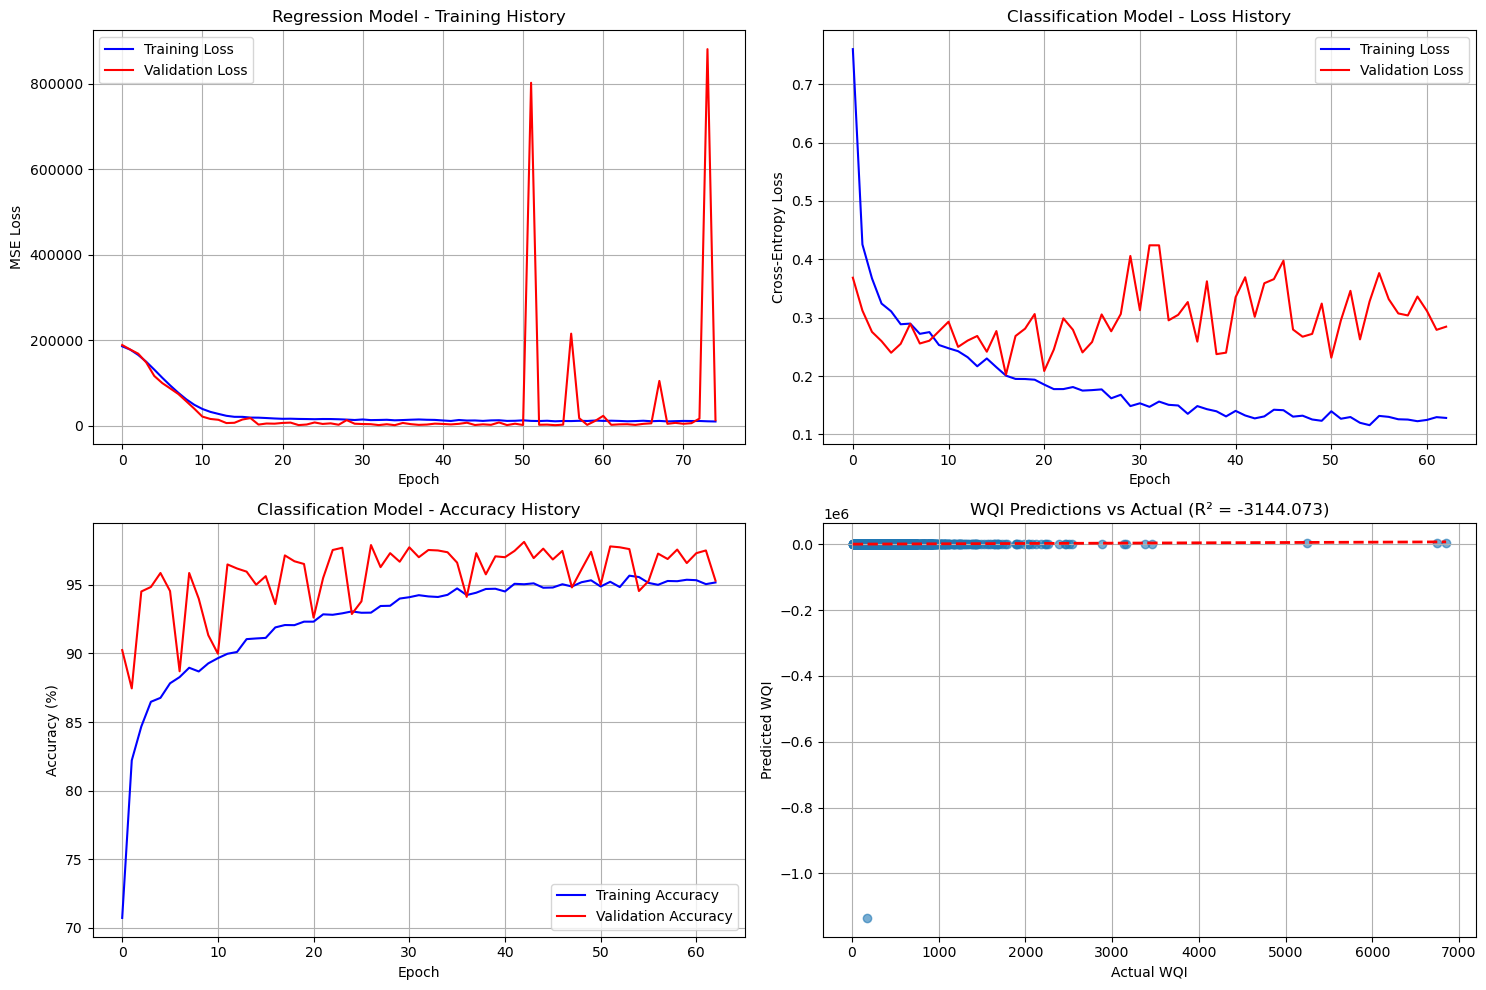

In [24]:

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Regression training curves
axes[0, 0].plot(reg_train_losses, label='Training Loss', color='blue')
axes[0, 0].plot(reg_val_losses, label='Validation Loss', color='red')
axes[0, 0].set_title('Regression Model - Training History')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Classification training curves - Loss
axes[0, 1].plot(clf_train_losses, label='Training Loss', color='blue')
axes[0, 1].plot(clf_val_losses, label='Validation Loss', color='red')
axes[0, 1].set_title('Classification Model - Loss History')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Cross-Entropy Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Classification training curves - Accuracy
axes[1, 0].plot(clf_train_accs, label='Training Accuracy', color='blue')
axes[1, 0].plot(clf_val_accs, label='Validation Accuracy', color='red')
axes[1, 0].set_title('Classification Model - Accuracy History')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Regression predictions vs actual
axes[1, 1].scatter(y_reg_test_tensor.numpy(), reg_predictions, alpha=0.6)
axes[1, 1].plot([y_reg_test_tensor.min(), y_reg_test_tensor.max()], 
                [y_reg_test_tensor.min(), y_reg_test_tensor.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Actual WQI')
axes[1, 1].set_ylabel('Predicted WQI')
axes[1, 1].set_title(f'WQI Predictions vs Actual (R² = {r2:.3f})')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

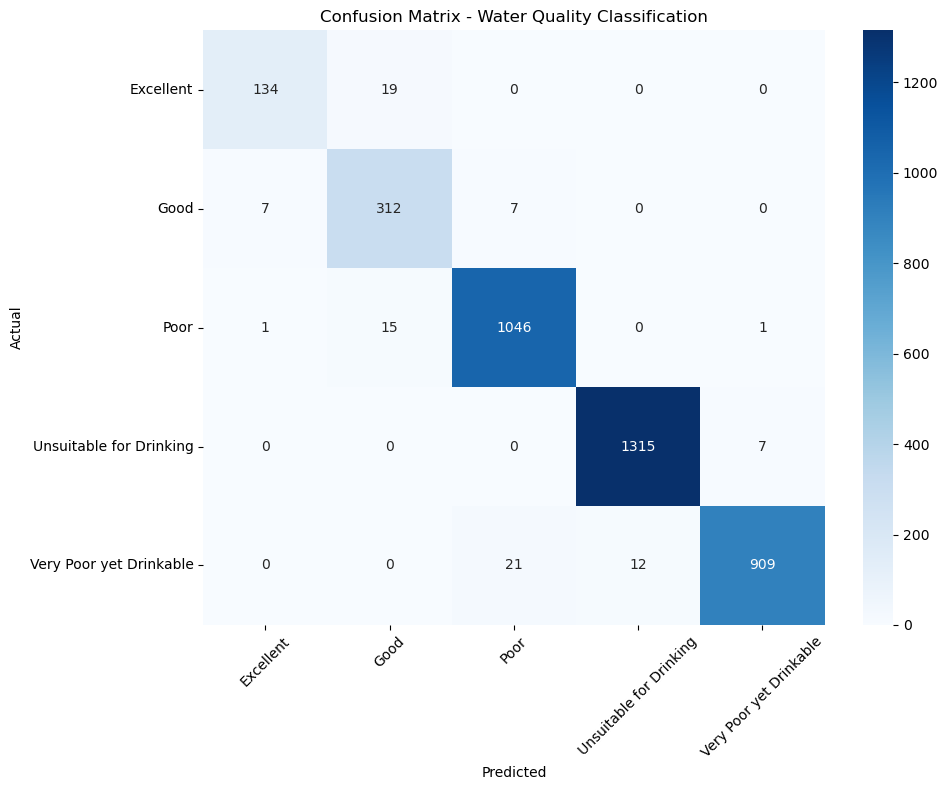

In [25]:
# Confusion Matrix for Classification
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_clf_test_tensor.numpy(), clf_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Water Quality Classification')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

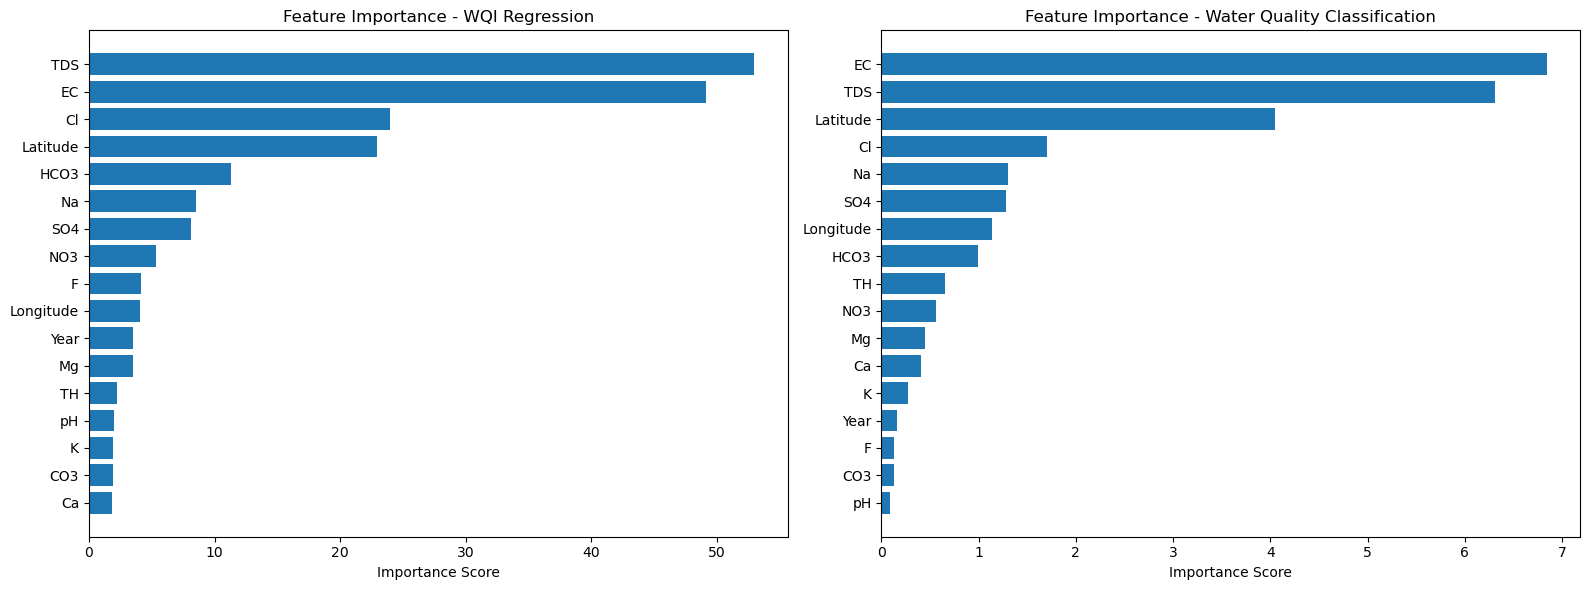

In [26]:
# Feature importance analysis (using gradient-based importance)
def get_feature_importance(model, X_sample, feature_names):
    """Calculate feature importance using gradient magnitudes"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    
    X_sample = X_sample.to(device).requires_grad_()
    outputs = model(X_sample)
    
    # For regression, use the output directly
    if outputs.shape[1] == 1:
        loss = outputs.sum()
    else:
        # For classification, use max probability
        loss = outputs.max(1)[0].sum()
    
    loss.backward()
    
    # Get gradient magnitudes
    gradients = X_sample.grad.abs().mean(0).cpu().numpy()
    
    return gradients

# Calculate feature importance for both models
reg_importance = get_feature_importance(regression_model, X_test_tensor[:100], feature_columns)
clf_importance = get_feature_importance(classification_model, X_test_tensor[:100], feature_columns)

# Plot feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Regression feature importance
sorted_idx_reg = np.argsort(reg_importance)
ax1.barh(range(len(feature_columns)), reg_importance[sorted_idx_reg])
ax1.set_yticks(range(len(feature_columns)))
ax1.set_yticklabels([feature_columns[i] for i in sorted_idx_reg])
ax1.set_title('Feature Importance - WQI Regression')
ax1.set_xlabel('Importance Score')

# Classification feature importance
sorted_idx_clf = np.argsort(clf_importance)
ax2.barh(range(len(feature_columns)), clf_importance[sorted_idx_clf])
ax2.set_yticks(range(len(feature_columns)))
ax2.set_yticklabels([feature_columns[i] for i in sorted_idx_clf])
ax2.set_title('Feature Importance - Water Quality Classification')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()


## 10. Model Saving and Inference Functions


In [27]:
def save_models_and_scaler():
    """Save trained models and scaler for future use"""
    import pickle
    
    # Save PyTorch models separately
    torch.save({
        'regression_model_state_dict': regression_model.state_dict(),
        'classification_model_state_dict': classification_model.state_dict(),
        'model_architecture': {
            'input_size': input_size,
            'num_classes': num_classes
        }
    }, 'water_quality_models.pth')
    
    # Save sklearn objects separately using pickle
    with open('preprocessing_objects.pkl', 'wb') as f:
        pickle.dump({
            'scaler': scaler,
            'label_encoder': label_encoder,
            'feature_columns': feature_columns,
            'class_names': class_names
        }, f)
    
    print("Models and preprocessing objects saved successfully!")

def load_models_and_predict(features):
    """Load models and make predictions on new data"""
    import pickle
    
    # Load PyTorch models with weights_only=True (secure)
    checkpoint = torch.load('water_quality_models.pth', weights_only=True)
    
    # Load preprocessing objects
    with open('preprocessing_objects.pkl', 'rb') as f:
        preprocessing = pickle.load(f)
    
    # Recreate models
    loaded_reg_model = WQIRegressionModel(checkpoint['model_architecture']['input_size'])
    loaded_clf_model = WaterQualityClassificationModel(
        checkpoint['model_architecture']['input_size'],
        checkpoint['model_architecture']['num_classes']
    )
    
    # Load state dicts
    loaded_reg_model.load_state_dict(checkpoint['regression_model_state_dict'])
    loaded_clf_model.load_state_dict(checkpoint['classification_model_state_dict'])
    
    # Set to evaluation mode
    loaded_reg_model.eval()
    loaded_clf_model.eval()
    
    # Scale features
    features_scaled = preprocessing['scaler'].transform(features.reshape(1, -1))
    features_tensor = torch.FloatTensor(features_scaled)
    
    with torch.no_grad():
        # WQI prediction
        wqi_pred = loaded_reg_model(features_tensor).item()
        
        # Classification prediction
        clf_outputs = loaded_clf_model(features_tensor)
        clf_prob = torch.softmax(clf_outputs, dim=1)
        clf_pred_idx = torch.argmax(clf_outputs, dim=1).item()
        clf_pred_label = preprocessing['label_encoder'].inverse_transform([clf_pred_idx])[0]
        
        # Get prediction confidence
        confidence = clf_prob.max().item()
    
    return {
        'predicted_wqi': wqi_pred,
        'predicted_class': clf_pred_label,
        'confidence': confidence,
        'class_probabilities': dict(zip(preprocessing['class_names'], clf_prob.numpy().flatten()))
    }

In [28]:
# Save models
save_models_and_scaler()

# Example inference on test data
sample_features = X_test.iloc[0].values
print("\n" + "="*50)
print("EXAMPLE PREDICTION")
print("="*50)

print("Input features:")
for i, feature in enumerate(feature_columns):
    print(f"{feature}: {sample_features[i]:.3f}")

prediction_result = load_models_and_predict(sample_features)

print(f"\nPredicted WQI: {prediction_result['predicted_wqi']:.2f}")
print(f"Predicted Class: {prediction_result['predicted_class']}")
print(f"Confidence: {prediction_result['confidence']:.3f}")

print(f"\nActual WQI: {y_reg_test.iloc[0]:.2f}")
print(f"Actual Class: {y_classification.iloc[X_test.index[0]]}")

print("\nClass Probabilities:")
for class_name, prob in prediction_result['class_probabilities'].items():
    print(f"{class_name}: {prob:.3f}")

Models and preprocessing objects saved successfully!

EXAMPLE PREDICTION
Input features:
Latitude: 81.207
Longitude: 27.908
Year: 2022.000
pH: 7.550
EC: 572.000
CO3: 0.000
HCO3: 341.600
Cl: 14.200
SO4: 5.000
NO3: 0.000
TH: 270.000
Ca: 88.000
Mg: 12.000
Na: 10.000
K: 6.200
F: 0.000
TDS: 489.000

Predicted WQI: 65.76
Predicted Class: Poor
Confidence: 0.995

Actual WQI: 173.44
Actual Class: Poor

Class Probabilities:
Excellent: 0.000
Good: 0.004
Poor: 0.995
Unsuitable for Drinking: 0.000
Very Poor yet Drinkable: 0.001



## 11. Summary and Conclusions


In [30]:

# Print a header for the model performance summary section
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)

# Display regression model metrics for WQI prediction
print("\n📊 REGRESSION MODEL (WQI Prediction):")
print(f"   • R² Score: {r2:.4f}")  # Coefficient of determination (higher is better)
print(f"   • RMSE: {rmse:.2f}")    # Root Mean Squared Error (lower is better)
print(f"   • MSE: {mse:.2f}")      # Mean Squared Error (lower is better)

# Display classification model metrics for water quality category prediction
print(f"\n🎯 CLASSIFICATION MODEL (Water Quality Category):")
print(f"   • Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")  # Percentage of correct predictions
print(f"   • F1 Score: {f1:.4f}")  # Harmonic mean of precision and recall

# Display dataset statistics
print(f"\n📈 DATASET STATISTICS:")
print(f"   • Total Samples: {len(df_processed):,}")  # Total number of data points
print(f"   • Training Samples: {len(X_train):,}")    # Number of samples used for training
print(f"   • Test Samples: {len(X_test):,}")         # Number of samples used for testing
print(f"   • Features: {len(feature_columns)}")      # Number of input features
print(f"   • Classes: {len(class_names)}")           # Number of target classes

# Display key insights from the model analysis
print(f"\n🔬 KEY INSIGHTS:")
print(f"   • Most important features for regression: {[feature_columns[i] for i in np.argsort(reg_importance)[-3:]]}")  # Top 3 features for regression
print(f"   • Most important features for classification: {[feature_columns[i] for i in np.argsort(clf_importance)[-3:]]}")  # Top 3 features for classification
print(f"   • Class distribution is imbalanced - 'Unsuitable for Drinking' is most common")  # Note on class imbalance
print(f"   • WQI ranges from {df_processed['WQI'].min():.1f} to {df_processed['WQI'].max():.1f}")  # Range of Water Quality Index values

# Display recommendations based on model performance and analysis
print(f"\n💡 RECOMMENDATIONS:")
print(f"   • The models can effectively predict both WQI values and water quality categories")
print(f"   • Chemical parameters like TDS, EC, and Cl appear to be strong predictors")
print(f"   • Consider ensemble methods or additional feature engineering for improvement")
print(f"   • Regular model retraining with new data is recommended")

# Print a footer to indicate the end of the analysis
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)


MODEL PERFORMANCE SUMMARY

📊 REGRESSION MODEL (WQI Prediction):
   • R² Score: -3144.0732
   • RMSE: 18402.87
   • MSE: 338665568.00

🎯 CLASSIFICATION MODEL (Water Quality Category):
   • Accuracy: 0.9764 (97.64%)
   • F1 Score: 0.9764

📈 DATASET STATISTICS:
   • Total Samples: 19,029
   • Training Samples: 15,223
   • Test Samples: 3,806
   • Features: 17
   • Classes: 5

🔬 KEY INSIGHTS:
   • Most important features for regression: ['Cl', 'EC', 'TDS']
   • Most important features for classification: ['Latitude', 'TDS', 'EC']
   • Class distribution is imbalanced - 'Unsuitable for Drinking' is most common
   • WQI ranges from 9.0 to 6850.9

💡 RECOMMENDATIONS:
   • The models can effectively predict both WQI values and water quality categories
   • Chemical parameters like TDS, EC, and Cl appear to be strong predictors
   • Consider ensemble methods or additional feature engineering for improvement
   • Regular model retraining with new data is recommended

ANALYSIS COMPLETE
